# HAR EDA (knu-2026)
Fresh look at the raw data before re-doing feature engineering. Goal: understand class signatures, direction/device quirks, and temporal structure.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

DATA_DIR = '/Users/dayana/git repo/machine-learning-class/lab6/knu-2026-machine-learning-final-assignment'

train_accel = pd.read_csv(f'{DATA_DIR}/train-accel.csv')
train_gyro  = pd.read_csv(f'{DATA_DIR}/train-gyro.csv')
train_label = pd.read_csv(f'{DATA_DIR}/train-label.csv')
test_accel  = pd.read_csv(f'{DATA_DIR}/test-accel.csv')
test_gyro   = pd.read_csv(f'{DATA_DIR}/test-gyro.csv')
test_label  = pd.read_csv(f'{DATA_DIR}/test-label.csv')

class_names = ['JumpJack','Jog','Squat','MtnClimb','PushUp','Burpee','Lunge','JumpSquat','Rest']

for name, df in [('train_accel',train_accel),('train_gyro',train_gyro),('train_label',train_label),
                  ('test_accel',test_accel),('test_gyro',test_gyro),('test_label',test_label)]:
    print(f"{name:12s} {df.shape}")


train_accel  (2428374, 7)
train_gyro   (2433673, 7)
train_label  (38015, 4)
test_accel   (2528310, 7)
test_gyro    (2541831, 7)
test_label   (39473, 4)


## 1. Class balance

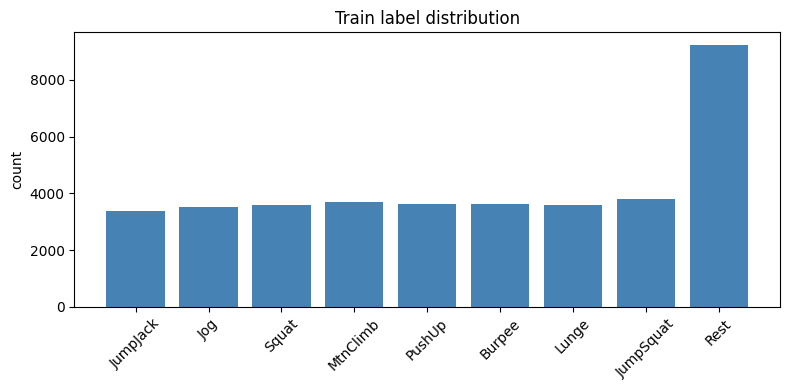

workout
0    3389
1    3523
2    3575
3    3697
4    3610
5    3627
6    3589
7    3795
8    9210
Name: count, dtype: int64

Max/min ratio (active classes 0-7): 1.12
Rest vs avg-active ratio: 2.56


In [2]:
counts = train_label['workout'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,4))
ax.bar([class_names[i] for i in counts.index], counts.values, color='steelblue')
ax.set_title('Train label distribution'); ax.set_ylabel('count')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()
print(counts)
print(f"\nMax/min ratio (active classes 0-7): {counts[:8].max()/counts[:8].min():.2f}")
print(f"Rest vs avg-active ratio: {counts[8]/counts[:8].mean():.2f}")


## 2. Device & direction breakdown

In [3]:
print("=== Device counts (rows) ===")
print("train:\n", train_accel['device'].value_counts())
print("\ntest:\n", test_accel['device'].value_counts())

print("\n=== Direction counts (rows) ===")
print("train:\n", train_accel['direction'].value_counts())
print("\ntest:\n", test_accel['direction'].value_counts())

dir_per_pid = train_accel.groupby('pid')['direction'].nunique()
multi_dir = dir_per_pid[dir_per_pid > 1]
print(f"\nTrain PIDs with >1 direction value: {len(multi_dir)} / {train_accel['pid'].nunique()}")
print(list(multi_dir.index))

dir_per_pid_test = test_accel.groupby('pid')['direction'].nunique()
multi_dir_test = dir_per_pid_test[dir_per_pid_test > 1]
print(f"\nTest PIDs with >1 direction value: {len(multi_dir_test)} / {test_accel['pid'].nunique()}")
print(list(multi_dir_test.index))


=== Device counts (rows) ===
train:
 device
samsung    1558848
Apple       869526
Name: count, dtype: int64

test:
 device
samsung    1564692
Apple       870850
unknown      92768
Name: count, dtype: int64

=== Direction counts (rows) ===
train:
 direction
1.0    1194014
2.0     637318
4.0     398435
3.0     198607
Name: count, dtype: int64

test:
 direction
1.0    1465995
2.0     728171
4.0     307429
3.0      26715
Name: count, dtype: int64

Train PIDs with >1 direction value: 21 / 58
['3C4K', '70N8', '7FRZ', '94BI', '9HJO', '9XOO', 'CDQ6', 'D1XP', 'DU2K', 'EUS2', 'F1ZM', 'IKYW', 'J2JZ', 'MEM8', 'P3LG', 'PYXQ', 'QJ18', 'RQFN', 'UWUT', 'VBMP', 'VN8D']

Test PIDs with >1 direction value: 4 / 39
['A78I', 'BEC3', 'KP89', 'TR3J']


## 3. Test-set quirks (PID-71, unknown device)

In [4]:
print("PID 71 rows in test_label:", (test_label['pid']=='71').sum())
print("PID 71 rows in test_accel:", (test_accel['pid']=='71').sum())
print("\ntest_label workout unique values:", test_label['workout'].unique())
print("\nUnknown-device rows - test_accel:", (test_accel['device']=='unknown').sum())
print("Unknown-device rows - test_gyro :", (test_gyro['device']=='unknown').sum())
print("\nPIDs in test with unknown device:", test_accel.loc[test_accel['device']=='unknown','pid'].unique())


PID 71 rows in test_label: 1124
PID 71 rows in test_accel: 0

test_label workout unique values: [-1]

Unknown-device rows - test_accel: 92768
Unknown-device rows - test_gyro : 92737

PIDs in test with unknown device: <StringArray>
['A1RZ', 'WKWS']
Length: 2, dtype: str


## 4. Sampling rate check

train_accel: median dt=0.01997s (~50.1 Hz) | p1=0.01884 p99=0.02124 max=11.464
train_gyro: median dt=0.01994s (~50.2 Hz) | p1=0.01852 p99=0.02124 max=11.478


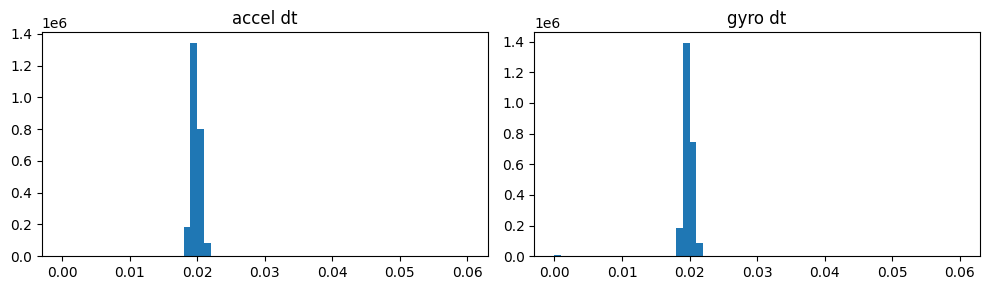

In [5]:
def dt_stats(df, name):
    dts = df.sort_values(['pid','time']).groupby('pid')['time'].diff().dropna()
    print(f"{name}: median dt={dts.median():.5f}s (~{1/dts.median():.1f} Hz) | "
          f"p1={dts.quantile(.01):.5f} p99={dts.quantile(.99):.5f} max={dts.max():.3f}")
    return dts

dt_acc = dt_stats(train_accel, 'train_accel')
dt_gyr = dt_stats(train_gyro, 'train_gyro')

fig, ax = plt.subplots(1,2, figsize=(10,3))
ax[0].hist(dt_acc.clip(0,0.06), bins=60); ax[0].set_title('accel dt')
ax[1].hist(dt_gyr.clip(0,0.06), bins=60); ax[1].set_title('gyro dt')
plt.tight_layout(); plt.show()


## 5. Direction correction (body frame)

In [6]:
def apply_direction_correction(df):
    df = df.copy()
    df['xb'], df['yb'], df['zb'] = df['x'].copy(), df['y'].copy(), df['z'].copy()
    for d,(sx,sy,sz) in {1:('y','-x','z'),2:('-y','x','z'),3:('y','-x','-z'),4:('-y','x','-z')}.items():
        m = df['direction']==d
        df.loc[m,'xb']=(df.loc[m,'x'] if sx=='x' else -df.loc[m,'x'] if sx=='-x' else df.loc[m,'y'] if sx=='y' else -df.loc[m,'y'])
        df.loc[m,'yb']=(df.loc[m,'x'] if sy=='x' else -df.loc[m,'x'] if sy=='-x' else df.loc[m,'y'] if sy=='y' else -df.loc[m,'y'])
        df.loc[m,'zb']=(df.loc[m,'z'] if sz=='z' else -df.loc[m,'z'])
    df['mag']=np.sqrt(df['x']**2+df['y']**2+df['z']**2)
    df['magb']=np.sqrt(df['xb']**2+df['yb']**2+df['zb']**2)
    return df

train_accel = apply_direction_correction(train_accel)
train_gyro  = apply_direction_correction(train_gyro)
print("done")


done


## 6. Example signal per class (raw x/y/z/mag, ~4s window)\nOne random sample per class. Look for: distinct shapes/frequencies, whether the confusable pairs (Squat/Lunge, PushUp/MtnClimb, Burpee/JumpSquat) look visually similar in raw frame.

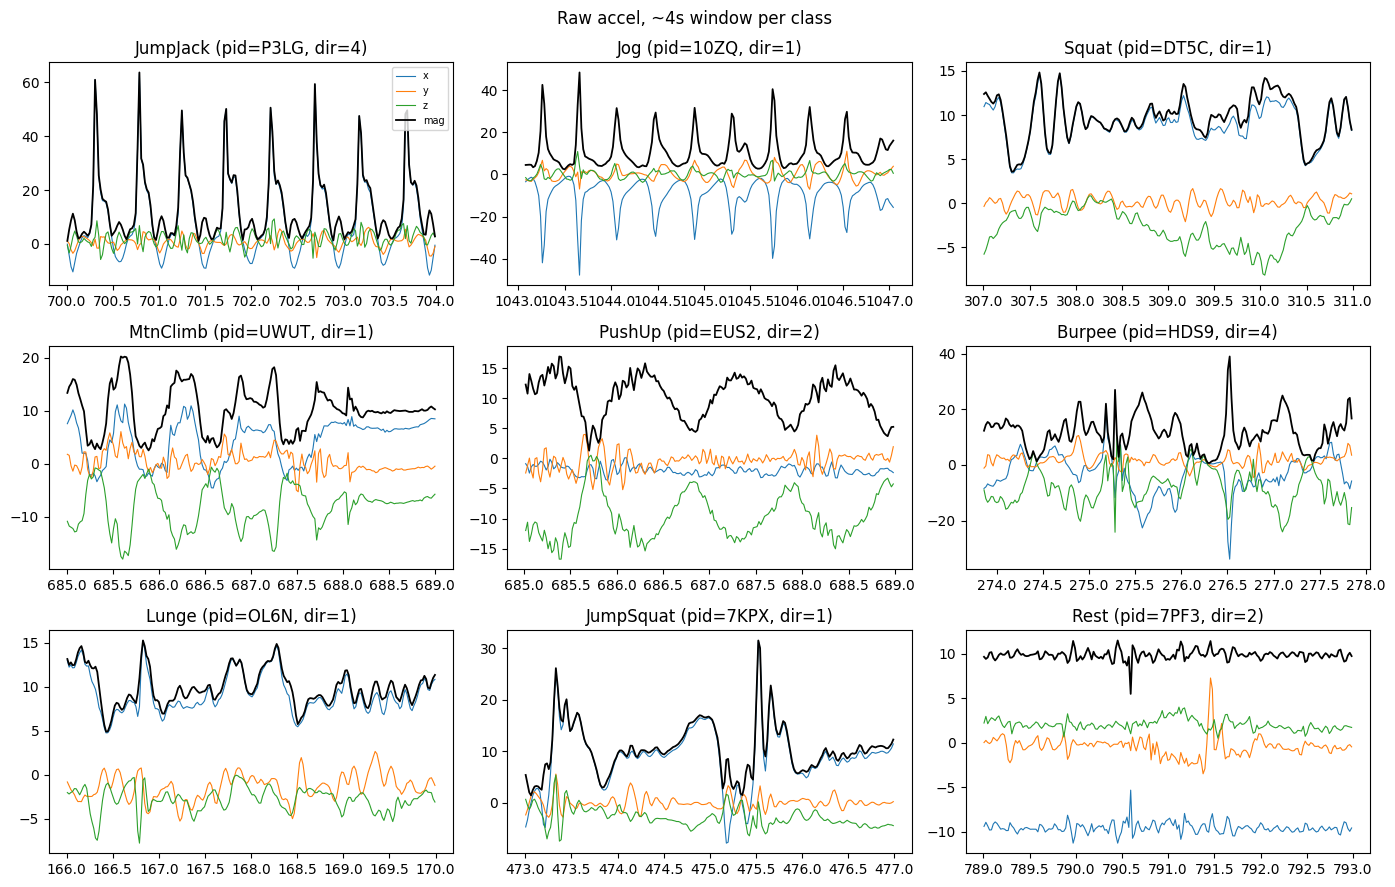

In [7]:
fig, axes = plt.subplots(3,3, figsize=(14,9))
for i, ax in enumerate(axes.flat):
    rows = train_label[train_label['workout']==i]
    r = rows.sample(1, random_state=1).iloc[0]
    pid, t0 = r['pid'], r['time']
    seg = train_accel[(train_accel['pid']==pid) & (train_accel['time'].between(t0-2, t0+2))]
    ax.plot(seg['time'], seg['x'], label='x', lw=0.8)
    ax.plot(seg['time'], seg['y'], label='y', lw=0.8)
    ax.plot(seg['time'], seg['z'], label='z', lw=0.8)
    ax.plot(seg['time'], seg['mag'], label='mag', lw=1.3, color='k')
    ax.set_title(f"{class_names[i]} (pid={pid}, dir={seg['direction'].iloc[0]:.0f})")
    if i==0: ax.legend(fontsize=7)
plt.suptitle("Raw accel, ~4s window per class")
plt.tight_layout(); plt.show()


## 7. Same windows, body-frame (zb=vertical, yb=fwd/back)\nDoes direction correction make orientation-sensitive classes (Squat, Lunge, PushUp, Burpee) more visually distinct/consistent?

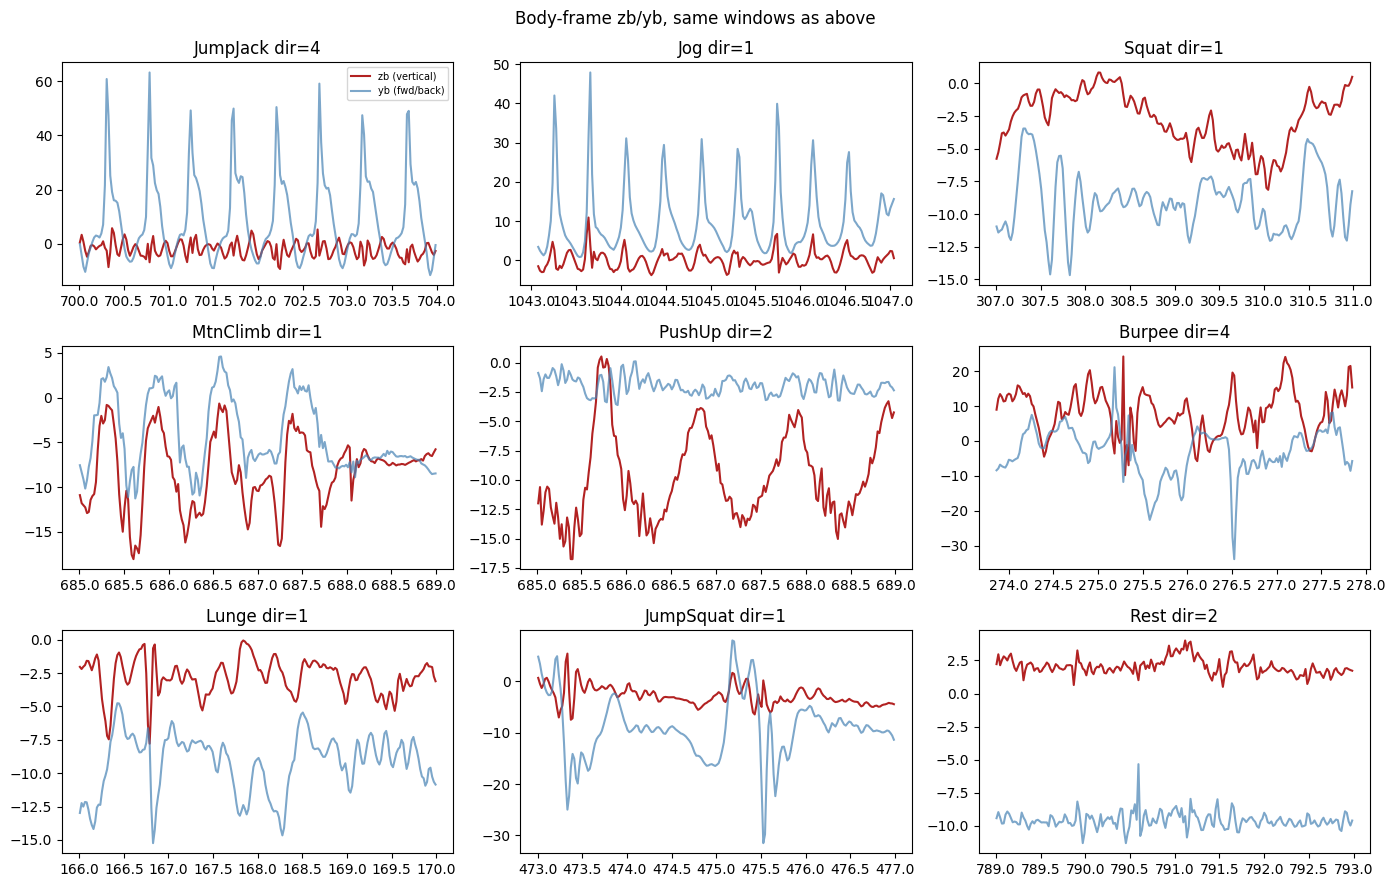

In [8]:
fig, axes = plt.subplots(3,3, figsize=(14,9))
for i, ax in enumerate(axes.flat):
    rows = train_label[train_label['workout']==i]
    r = rows.sample(1, random_state=1).iloc[0]
    pid, t0 = r['pid'], r['time']
    seg = train_accel[(train_accel['pid']==pid) & (train_accel['time'].between(t0-2, t0+2))]
    ax.plot(seg['time'], seg['zb'], label='zb (vertical)', color='firebrick')
    ax.plot(seg['time'], seg['yb'], label='yb (fwd/back)', color='steelblue', alpha=0.7)
    ax.set_title(f"{class_names[i]} dir={seg['direction'].iloc[0]:.0f}")
    if i==0: ax.legend(fontsize=7)
plt.suptitle("Body-frame zb/yb, same windows as above")
plt.tight_layout(); plt.show()


## 8. Confusable-pair feature distributions (instantaneous)

In [9]:
def nearest_join(label_df, sensor_df, cols, suffix):
    sensor_groups = {pid: g.sort_values('time') for pid, g in sensor_df.groupby('pid')}
    res = []
    for pid, grp in label_df.groupby('pid'):
        if pid not in sensor_groups: continue
        m = pd.merge_asof(grp.sort_values('time'), sensor_groups[pid], on='time', direction='nearest')
        res.append(m)
    out = pd.concat(res)
    return out[['workout']+cols].rename(columns={c: f'{c}_{suffix}' for c in cols})

feat_a = nearest_join(train_label, train_accel, ['mag','magb','zb'], 'a')
feat_g = nearest_join(train_label, train_gyro, ['mag','magb'], 'g')
feats = pd.concat([feat_a, feat_g.drop(columns='workout')], axis=1)
print(feats.shape)


(38015, 6)


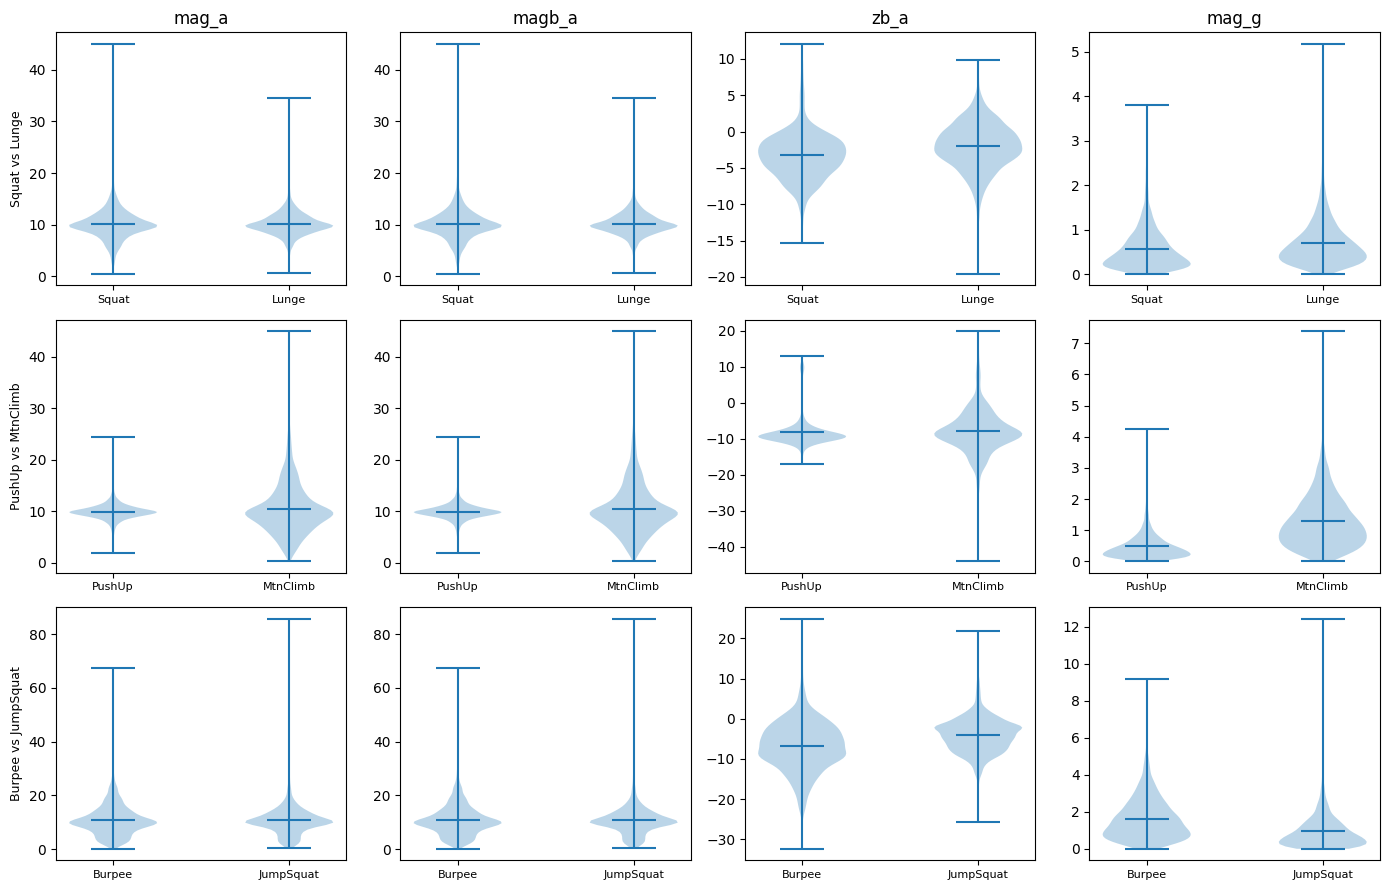

In [10]:
pairs = [(2,6,'Squat vs Lunge'), (4,3,'PushUp vs MtnClimb'), (5,7,'Burpee vs JumpSquat')]
cols_to_plot = ['mag_a','magb_a','zb_a','mag_g']
fig, axes = plt.subplots(len(pairs), len(cols_to_plot), figsize=(14,9))
for r,(c1,c2,title) in enumerate(pairs):
    for c, col in enumerate(cols_to_plot):
        ax = axes[r,c]
        d1 = feats.loc[feats.workout==c1, col]
        d2 = feats.loc[feats.workout==c2, col]
        ax.violinplot([d1,d2], showmeans=True)
        ax.set_xticks([1,2]); ax.set_xticklabels([class_names[c1],class_names[c2]], fontsize=8)
        if r==0: ax.set_title(col)
        if c==0: ax.set_ylabel(title, fontsize=9)
plt.tight_layout(); plt.show()


## 9. Temporal structure of labels (smoothing justification)

P(label[t+1]==label[t]) per pid: mean=0.948, min=0.886


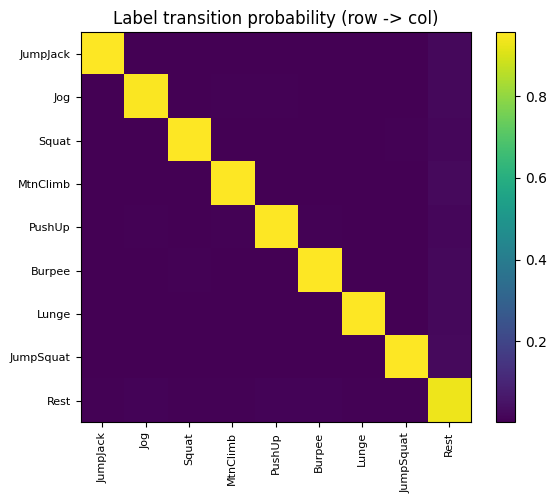

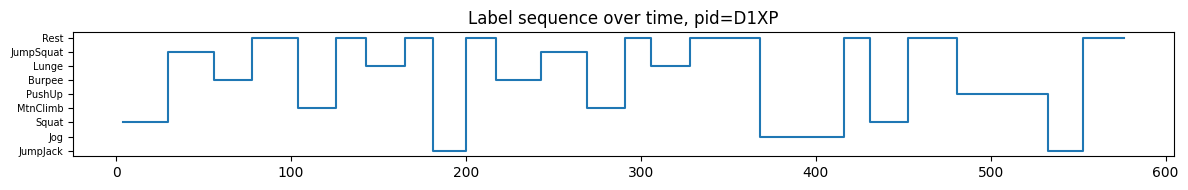

In [11]:
same_next = []
all_w = []
for pid, grp in train_label.groupby('pid'):
    w = grp.sort_values('time')['workout'].values
    all_w.append(w)
    same_next.append((w[:-1]==w[1:]).mean())
same_next = np.array(same_next)
print(f"P(label[t+1]==label[t]) per pid: mean={same_next.mean():.3f}, min={same_next.min():.3f}")

trans = np.zeros((9,9))
for w in all_w:
    for a,b in zip(w[:-1], w[1:]):
        trans[a,b]+=1
trans_norm = trans / trans.sum(1, keepdims=True)

fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(trans_norm, cmap='viridis')
ax.set_xticks(range(9)); ax.set_xticklabels(class_names, rotation=90, fontsize=8)
ax.set_yticks(range(9)); ax.set_yticklabels(class_names, fontsize=8)
ax.set_title('Label transition probability (row -> col)')
plt.colorbar(im); plt.tight_layout(); plt.show()

pid_ex = train_label['pid'].iloc[0]
seq = train_label[train_label['pid']==pid_ex].sort_values('time')
fig, ax = plt.subplots(figsize=(12,2))
ax.step(seq['time'], seq['workout'], where='post')
ax.set_yticks(range(9)); ax.set_yticklabels(class_names, fontsize=7)
ax.set_title(f'Label sequence over time, pid={pid_ex}')
plt.tight_layout(); plt.show()


## 10. Notes / what to check next\n- If raw vs body-frame (sec 6 vs 7) look similar for a class, direction correction isn't adding info for it.\n- If section 8 violins show heavy overlap for a pair, that pair needs a *new* discriminative feature, not more of the same stat types.\n- High P(label[t+1]==label[t]) and a near-diagonal transition matrix (sec 9) support smoothing and/or sequence-aware models (e.g. adding lag/lead label-adjacent features, HMM-style post-processing).\n- Re-check multi-direction PIDs (sec 2) against section 8 — do they show up as outliers in zb/magb?